# COGS 150 Final Project: Testing Subject-Verb Agreement in Spanish LLMs
*by Roxana Chen*

## Introduction & Background

My project will be testing the sensitivity of LLMs to subject-verb agreement in Spanish. My idea is based off of the paper published by Linzen et. al. in 2016, titled "Assessing the Ability of LSTMs to Learn Syntax-Sensitive Dependencies", where the authors examined how sensitive English LSTM neural networks are to **subject-verb agreement**<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1). In this study, they used intervening nouns that differ in number from the subject called agreement attraction errors, or more simply referred to as **attractors**, which mislead the model as to what a correct verb conjugation would be for a given subject. What they found was a deterioration in performance by the LSTMs when there was just one or more attractors, showing that LSTMs were *not* sensitive to subject-verb agreement. 

Later studies such as that of Hu et. al. in 2020 showed that LLMs, rather than LSTMs, actually *are* sensitive to subject-verb agreement, specifically GPT-2, but are less so than humans<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2). A following study the same authors performed in 2024 also tested LLMs and found that advancements in current models like GPT-3 and above are not only just as sensitive to subject-verb agreement as humans, but also can even *outperform* humans<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3). 

With all of these findings, I became interested in seeing where the performance of a **Spanish LLM** falls among them. My speculation is that despite the fact that non-English LLMs are certainly less advanced than the English counterparts, perhaps since Spanish verb conjugations are more complex and are more specific to a subject than English ones, a language model trained on Spanish data would still be sensitive to subject-verb agreement. Therefore, going into this project, **I anticipate seeing high surprisal values for subject-verb agreement violations.**



1. <a name="cite_note-1"></a> [^](#cite_ref-1) Linzen, T., Dupoux, E., & Goldberg, Y. (2016). Assessing the ability of LSTMs to learn syntax-sensitive dependencies. Transactions of the Association for Computational Linguistics, 4, 521–535. https://doi.org/10.1162/tacl_a_00115
3. <a name="cite_note-2"></a> [^](#cite_ref-2) Hu, J., Gauthier, J., Qian, P., Wilcox, E., & Levy, R. P. (2020). A systematic assessment of syntactic generalization in neural language models. Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics, 1725–1744. https://doi.org/10.18653/v1/2020.acl-main.158
4. <a name="cite_note-3"></a> [^](#cite_ref-3) Hu, J., Mahowald, K., Lupyan, G., Ivanova, A., & Levy, R. (2024). Language models align with human judgments on key grammatical constructions. Proceedings of the National Academy of Sciences, 121(36), e2400917121. https://doi.org/10.1073/pnas.2400917121

## Methodolody

### Linzen et. al.'s Methodology
I chose to replicate the methodology used in the Linzen et. al. (2016) paper, where the authors constructed sentences with four variations of subject-verb agreement and systematically varied the number of attractors, ranging from 0 to 3. They tested both singular and plural forms for subjects and intervening nouns, such as:

* The key is on the table
* The keys is on the table* 
* The key are on the table*
* The keys are on the table

where sentences marked with an asterisk (*) violate subject-verb agreement. They then calculated the model's surprisal values for each verb form and compared those results to assess whether it correctly predicted grammatical agreement. Finally, the model's performance was analyzed across different levels of syntactic interference by measuring how accurately the model preferred the correct verb form as the number of attractor nouns between the subject and verb increased from none to up to three attractors.

### My Replication

For my experiment, I replicated this methodology in Spanish by creating my stimuli using 2 base sentence templates (“El perro…” and “La estudiante…”) tested across 3 levels of syntactic interference (0, 1, or 2 attractor nouns). At each attractor level, each sentence template is used to generate 4 sentence variants that manipulate grammaticality by changing the number (singular/plural) of the subject and the verb:

* el/el (grammatical)
* el/ellos* (ungrammatical)
* ellos/el* (ungrammatical)
* ellos/ellos (grammatical)

This results in 24 sentences total, made from 6 groups (2 sentence templates × 3 attractor levels). Each group has 4 sentence versions: 2 grammatical and 2 ungrammatical. Each grammatical vs. ungrammatical pair counts as a “minimal pair”, so there are 12 minimal pairs altogether.

Since the variable I am manipulating is **attractors**, I'm mainly interested in whether or not sensitivity will hold up in their presence. Using these stimuli, I will test whether or not the model is sensitive to subject-verb agreement by calculating surprisal for each sentence. If there is sensitivity to subject-verb agreement, I expect that there will be higher surprisal to ungrammatical sentences where the subject and verb disagree, even with intervening attractors.

The model I will be using is one called GPT2-Spanish from DeepESP, gotten off of HuggingFace (https://huggingface.co/DeepESP/gpt2-spanish).

## Confounds, Validities, & Limitations

Because I based my experimental design entirely off of Linzen et. al's design, which was a proven methodology, my experiment has a lot of strengths; the minimal pair structure supports strong **internal validity** by changing only the agreement between subject and verb, while keeping the rest of the sentence the same. Additionally, there is counterbalancing with the 4 variants of subject-verb agreement (el/el, el/ellos, ellos/el, and ellos/ellos) which ensures that I'm **covering all directionality** and my results are not biased towards one direction of mismatching agreement. Since I'm manipulating the number of attractors, I also have a **control group** by testing the surprisal for 0 attractors, which is necessary for internal validity.

That said, there are limitations to my project. It is important to mention that I chose to use only 12 minimal pairs (across two sentence templates, giving 24 total sentences) since the scale of this project is not a full-blown analysis. While intentional, I am using a small sample size, which lowers the **statistical validity** of my project, since it limits the power to detect reliable effects and makes the results more sensitive to chance or idiosyncrasies in my sentences. This also may interfere with **external validity**, because the small batch of sentences may not represent broader patterns in Spanish and are thus not generalizeable. Additionally, Spanish has a **more flexible word order** than English, with the order in which subjects and verbs are presented in a sentence being more variable, which could further complicate how subject-verb agreement is processed by the model. On top of this, the Spanish data that the model was trained on is **less robust** and may be **biased** towards certain verbs that it may have seen conjugated more often, and my sentence stimuli may be affected by this. More generally, a big limitation of this project is the Spanish LLM itself, which is relatively **underpowered** compared to its English counterparts as previously mentioned (roughly the size of GPT-2 small, not GPT-2-XL); a larger model would make for more reliable results. 


## Analysis

### Importing Packages

Now, it's time to get into the actual analysis. I'll start by loading in the packages I need, as well as the GPT2-Spanish model from DeepESP.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

%matplotlib inline
%config InlineBackend.figure_format = 'retina'  # makes figs nicer!

In [6]:
# %pip install transformers # uncomment if needed

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import math

# Load Spanish GPT-2 model
tokenizer = AutoTokenizer.from_pretrained("DeepESP/gpt2-spanish")
model = AutoModelForCausalLM.from_pretrained("DeepESP/gpt2-spanish")
model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

### Defining Necessary Functions

There are two self-defined functions I'll need in order to get my results: 

`next_seq_prob`: gets the probability of a next token

`surprisal`: calculates surprisal (big surprise!)

In [7]:
def next_seq_prob(model, tokenizer, seen, unseen):
    """Get p(unseen | seen)

    Parameters
    ----------
    model : transformers.PreTrainedModel
        Model to use for predicting tokens
    tokenizer : transformers.PreTrainedTokenizer
        Tokenizer for Model
    seen : str
        Input sequence
    unseen: str
        The sequence for which to calculate a probability
    """
    # Get ids for tokens
    input_ids = tokenizer.encode(seen, return_tensors="pt")
    unseen_ids = tokenizer.encode(unseen)

    # Loop through unseen tokens & store log probs
    log_probs = []
    for unseen_id in unseen_ids:

        # Run model on input
        with torch.no_grad():
            logits = model(input_ids).logits

        # Get next token prediction logits
        next_token_logits = logits[0, -1]
        next_token_probs = torch.softmax(next_token_logits, 0) # Normalize

        # Get probability for relevant token in unseen string & store
        prob = next_token_probs[unseen_id]
        log_probs.append(torch.log(prob))

        # Add input tokens incrementally to input
        input_ids = torch.cat((input_ids, torch.tensor([[unseen_id]])), 1)

    # Add log probs together to get total log probability of sequence
    total_log_prob = sum(log_probs)
    # Exponentiate to return to probabilities
    total_prob = torch.exp(total_log_prob)
    return total_prob.item()

In [99]:
def surprisal(p):
  return -np.log2(p)

### Creating Psycholinguistic Stimuli

Now, I'll create the stimuli according to the methodology I defined above and put them into a dataframe.

In [9]:
stimuli = [
    # attractors, sentence number, agreement type, sentence, target verb, condition
    (0,	'sentence 1', 'el/el', 'El perro', 'ladra', 'grammatical'),
    (0,	'sentence 1', 'el/ellos', 'El perro', 'ladran', 'ungrammatical'),
    (0,	'sentence 1', 'ellos/el', 'Los perros', 'ladra', 'ungrammatical'),
    (0,	'sentence 1', 'ellos/ellos', 'Los perros', 'ladran', 'grammatical'),
    (1,	'sentence 1', 'el/el', 'El perro de los vecinos', 'ladra', 'grammatical'),
    (1,	'sentence 1', 'el/ellos', 'El perro de los vecinos', 'ladran', 'ungrammatical'),
    (1,	'sentence 1', 'ellos/el', 'Los perros de los vecinos', 'ladra', 'ungrammatical'),
    (1,	'sentence 1', 'ellos/ellos', 'Los perros de los vecinos', 'ladran', 'grammatical'),
    (2,	'sentence 1', 'el/el', 'El perro de los vecinos y de las primas', 'ladra', 'grammatical'),
    (2,	'sentence 1', 'el/ellos', 'El perro de los vecinos y de las primas', 'ladran', 'ungrammatical'),
    (2,	'sentence 1', 'ellos/el', 'Los perros de los vecinos y de las primas', 'ladra', 'ungrammatical'),
    (2,	'sentence 1', 'ellos/ellos', 'Los perros de los vecinos y de las primas', 'ladran', 'grammatical'),
    (0,	'sentence 2', 'el/el', 'La estudiante', 'estudia', 'grammatical'),
    (0,	'sentence 2', 'el/ellos', 'La estudiante', 'estudian', 'ungrammatical'),
    (0,	'sentence 2', 'ellos/el', 'Las estudiantes', 'estudia', 'ungrammatical'),
    (0,	'sentence 2', 'ellos/ellos', 'Las estudiantes', 'estudian', 'grammatical'),
    (1,	'sentence 2', 'el/el', 'La estudiante de los amigos', 'estudia', 'grammatical'),
    (1,	'sentence 2', 'el/ellos', 'La estudiante de los amigos', 'estudian', 'ungrammatical'),
    (1,	'sentence 2', 'ellos/el', 'Las estudiantes de los amigos', 'estudia', 'ungrammatical'),
    (1,	'sentence 2', 'ellos/ellos', 'Las estudiantes de los amigos', 'estudian', 'grammatical'),
    (2,	'sentence 2', 'el/el', 'La estudiante de los amigos y de las primas', 'estudia', 'grammatical'),
    (2,	'sentence 2', 'el/ellos', 'La estudiante de los amigos y de las primas', 'estudian', 'ungrammatical'),
    (2,	'sentence 2', 'ellos/el', 'Las estudiantes de los amigos y de las primas', 'estudia', 'ungrammatical'),
    (2,	'sentence 2', 'ellos/ellos', 'Las estudiantes de los amigos y de las primas', 'estudian', 'grammatical'),
]

In [10]:
### Create DataFrame
df_stimuli = pd.DataFrame(stimuli, columns = ['attractors', 'sentence_num', 'agreement_type', 'sentence', 'target_verb', 'condition'])
df_stimuli.head()

,attractors,sentence_num,agreement_type,sentence,target_verb,condition
0,0,sentence 1,el/el,El perro,ladra,grammatical
1,0,sentence 1,el/ellos,El perro,ladran,ungrammatical
2,0,sentence 1,ellos/el,Los perros,ladra,ungrammatical
3,0,sentence 1,ellos/ellos,Los perros,ladran,grammatical
4,1,sentence 1,el/el,El perro de los vecinos,ladra,grammatical


## Results

In order to actually get my results, I need to pass my stimuli through the model and calculate surprisal for each sentence.

In [12]:
results = []
for index, row in tqdm(df_stimuli.iterrows(), total=df_stimuli.shape[0]):

    prob = next_seq_prob(model, tokenizer, row['sentence'], row['target_verb'])

    results.append({
        'Word': row['target_verb'],
        'Sentence': row['sentence'],
        'Condition': row['condition'],
        'Attractors': row['attractors'],
        'Sentence Number': row['sentence_num'],
        'Agreement Type': row['agreement_type'],

        'Probability': prob,
        'Surprisal': surprisal(prob)
    })


100%|██████████| 24/24 [00:01<00:00, 23.63it/s]


In [13]:
### Create DataFrame
df_results = pd.DataFrame(results)
df_results.head()

,Word,Sentence,Condition,Attractors,Sentence Number,Agreement Type,Probability,Surprisal
0,ladra,El perro,grammatical,0,sentence 1,el/el,2.824393e-12,38.365196
1,ladran,El perro,ungrammatical,0,sentence 1,el/ellos,4.419980e-12,37.719097
2,ladra,Los perros,ungrammatical,0,sentence 1,ellos/el,2.037401e-12,38.836407
3,ladran,Los perros,grammatical,0,sentence 1,ellos/ellos,4.111804e-12,37.823366
4,ladra,El perro de los vecinos,grammatical,1,sentence 1,el/el,2.461489e-11,35.241678


Putting my results into a dataframe, you can see that just by taking a quick glance at the calculated surprisal of the first few rows, there doesn't seem to be much of a difference between grammatical and ungrammatical sentences, even for the control group of 0 attractors. That makes me speculate that for the further manipulations of attractors, there is presumably no difference between grammatica, and ungrammatical sentences in those conditions. I can assume just from the first few results that there is not a sensitivity to subject-verb agreement in this particular model. In order to really understand the results without just examining the full dataframe, I will visualize the results instead.

## Results, Visualized

When visualizing my results, I will be using standard deviation for my error bars rather than the default standard error of the mean because this experiment has a small n, and I don't want that to downplay the variability seen in my results.

In [38]:
# SETTING COLOR PALETTES

condition_palette = { 
    # intuitive colors of green for correct grammar and red for incorrect, but colorblind-friendly
    
    "grammatical": "#1b9e77",      # green
    "ungrammatical": "#d95f02"     # orange
}

agreement_palette = { 
    # different colors than condition palette
    # matching conditions (el/el & ellos/ellos) have similar colors while unmatching (el/ellos & ellos/el) have similar colors
    # unmatching conditions are pink, close to red to intuitively emphasize incorrectness
    
    "el/el": "#1f77b4",       # navy blue
    "el/ellos": "#e377c2",    # light pink
    "ellos/el": "#e7298a",    # darker pink
    "ellos/ellos": "#17becf"  # cyan
}

### Surprisal by Grammaticality, Mean & Across Attractors

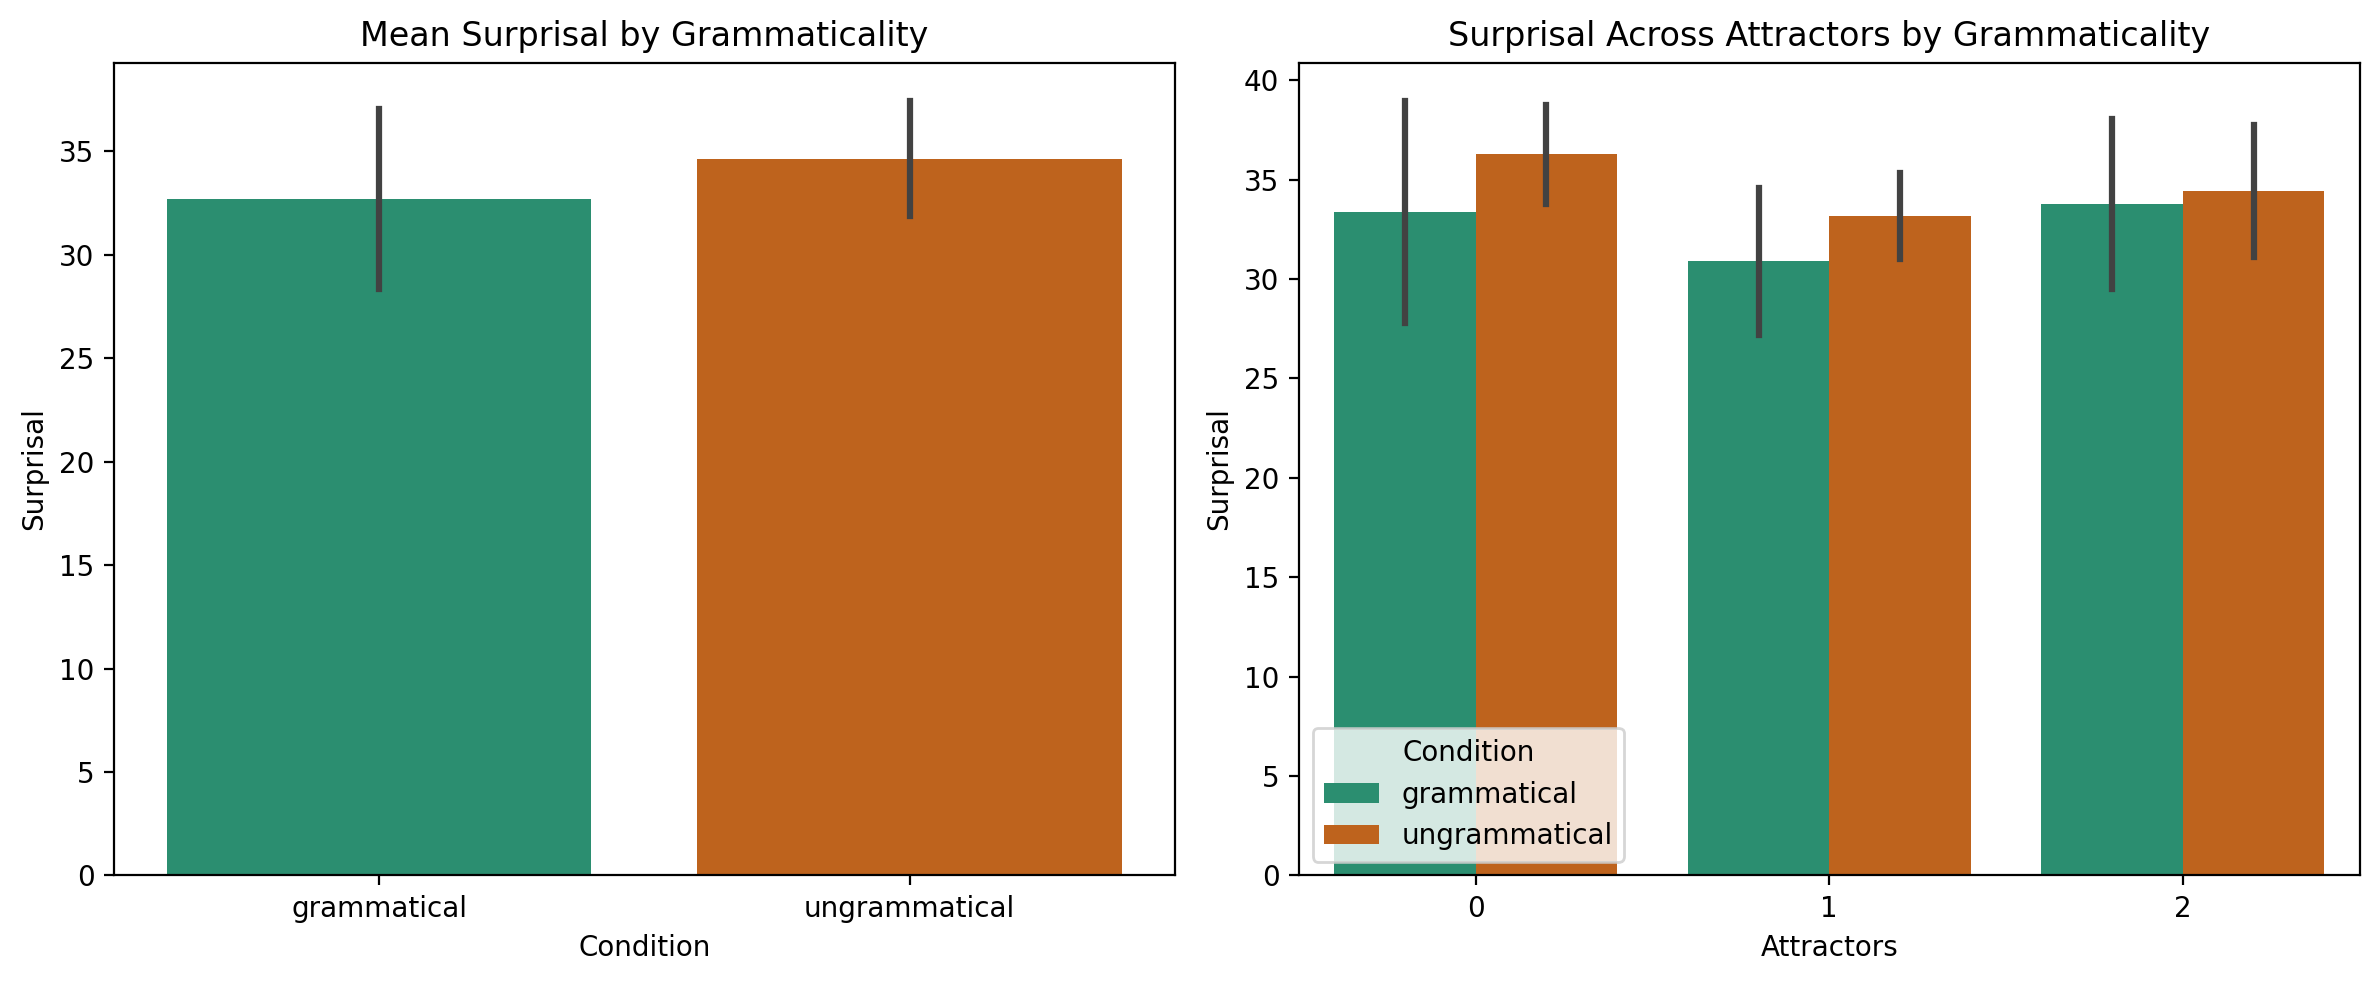

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# first plot: Surprisal by Condition
sns.barplot(
    data = df_results,
    x = 'Condition',
    y = 'Surprisal',
    hue = 'Condition',
    palette = condition_palette,
    errorbar = 'sd',
    ax = axes[0]
)
axes[0].set_title('Mean Surprisal by Grammaticality')

# second plot: Surprisal across Attractors
sns.barplot(
    data = df_results,
    x = 'Attractors',
    y = 'Surprisal',
    hue = 'Condition',
    palette = condition_palette,
    errorbar = 'sd',
    ax = axes[1]
)
axes[1].set_title('Surprisal Across Attractors by Grammaticality')

plt.tight_layout()
plt.show()

Looking at these graphs, I can see that mean surprisal is almost the same between grammatical and ungrammatical conditions, only slightly lower for grammatical which does not seem to be a significant difference as seen by the error bars largely overlapping. Then, for surprisal across attractors, this is pretty much the same; although there is a lower surprisal overall (for both grammaticality conditions) with 1 attractor compared to the 0 and 2 attractors, possibly suggesting that there is less sensitivity overall to the both verb conjugations with one attractor. additionally, the two attractor condition has the smallest difference in surprisal between grammatical and ungrammatical sentences compared to the 0 and 1 attractor conditions, which could possibly suggest less sensitivity to subject-verb agreement with 2 attractors. But again, these differences appear very miniscule with large error bars, so it's hard to say for certain just by looking at it. I would lean towards saying there is little to no sensitivity to subject-verb agreement from looking at these graphs, though an official conclusion would have to be made by running a statistical test (which I believe would turn out that it is not significant).

### Surprisal by Grammaticality Distribution

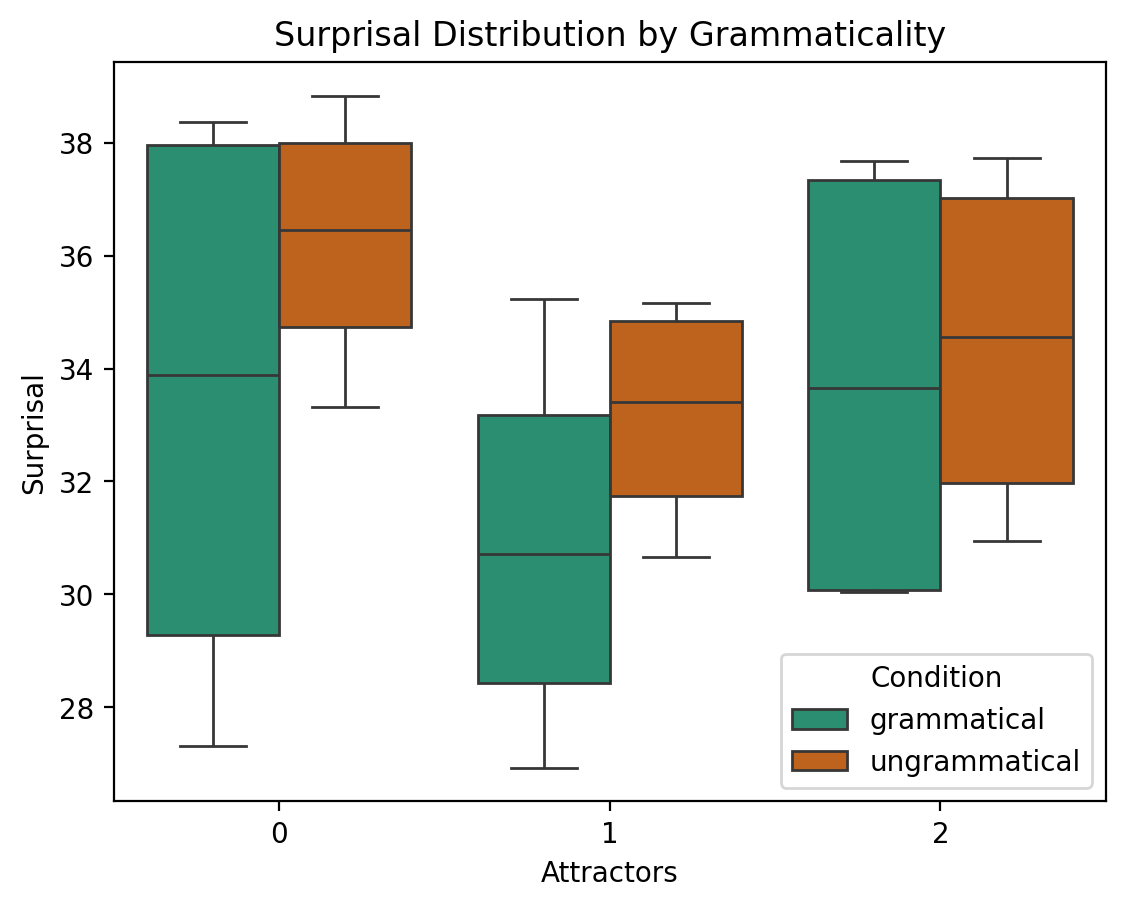

In [117]:
sns.boxplot(data = df_results, x = 'Attractors', y = 'Surprisal', hue = 'Condition', palette = condition_palette)
plt.title('Surprisal Distribution by Grammaticality')
plt.show()

Looking at the distribution of surprisal across the different numbers of attractors, I can more clearly see that there seems to be a decreasing difference between the medians of grammatical vs ungrammatical conditions as the number of attractors increases; the medians between the grammaticality conditions appears to become closer and closer together from 0-2 attractors, with the 2 attractor condition having a lot closer medians than the 0 and 1 attractor conditions. The median for ungrammatical conditions also again is higher than the grammatical conditions, reflecting a slightly higher surprisal value for ungrammatical conditions, showing a slight sensitivity to subject-verb agreement that deteriorates as attractors increase in number.

### Attractors & Grammaticality: Interaction

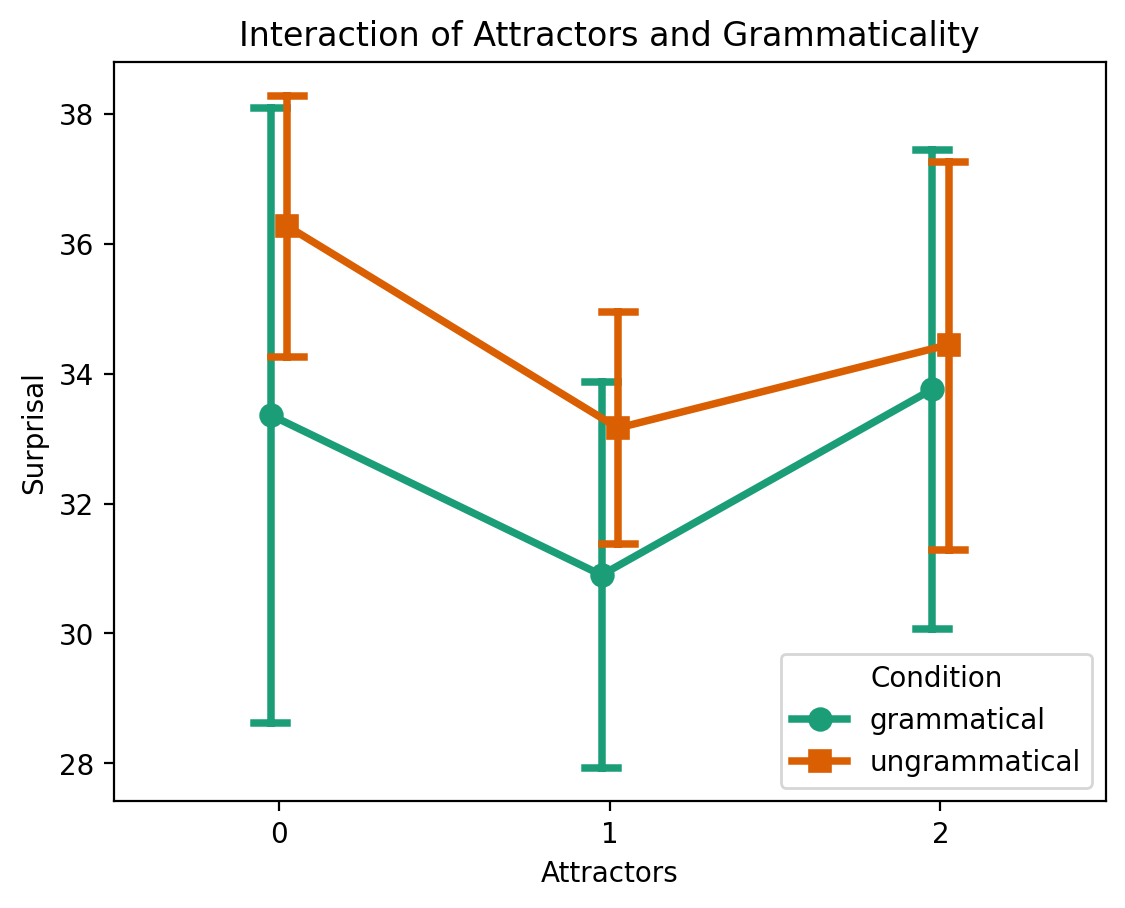

In [63]:
sns.pointplot(
    data = df_results,
    x = 'Attractors',
    y = 'Surprisal',
    hue = 'Condition',
    palette = condition_palette,
    dodge = True,
    markers = ['o', 's'],
    capsize = 0.1
)
plt.title('Interaction of Attractors and Grammaticality')
plt.show()

This graph more clearly shows that the surprisal gap between grammatical and ungrammatical sentences is largest with 0 attractors, shrinks slightly (and almost unnoticeably) at 1 attractor, and shrinks significantly at 2. This suggests the model is most sensitive to agreement violations when there's no interference, and its sensitivity weakens increasingly under increasing interference from attractors. This mirrors the findings initally found in Linzen et. al.'s paper, showing that the GPT2-Spanish model performs on par with that of LSTMs from 2016.

### Surprisal by Agreement Type, Mean & Across Attractors

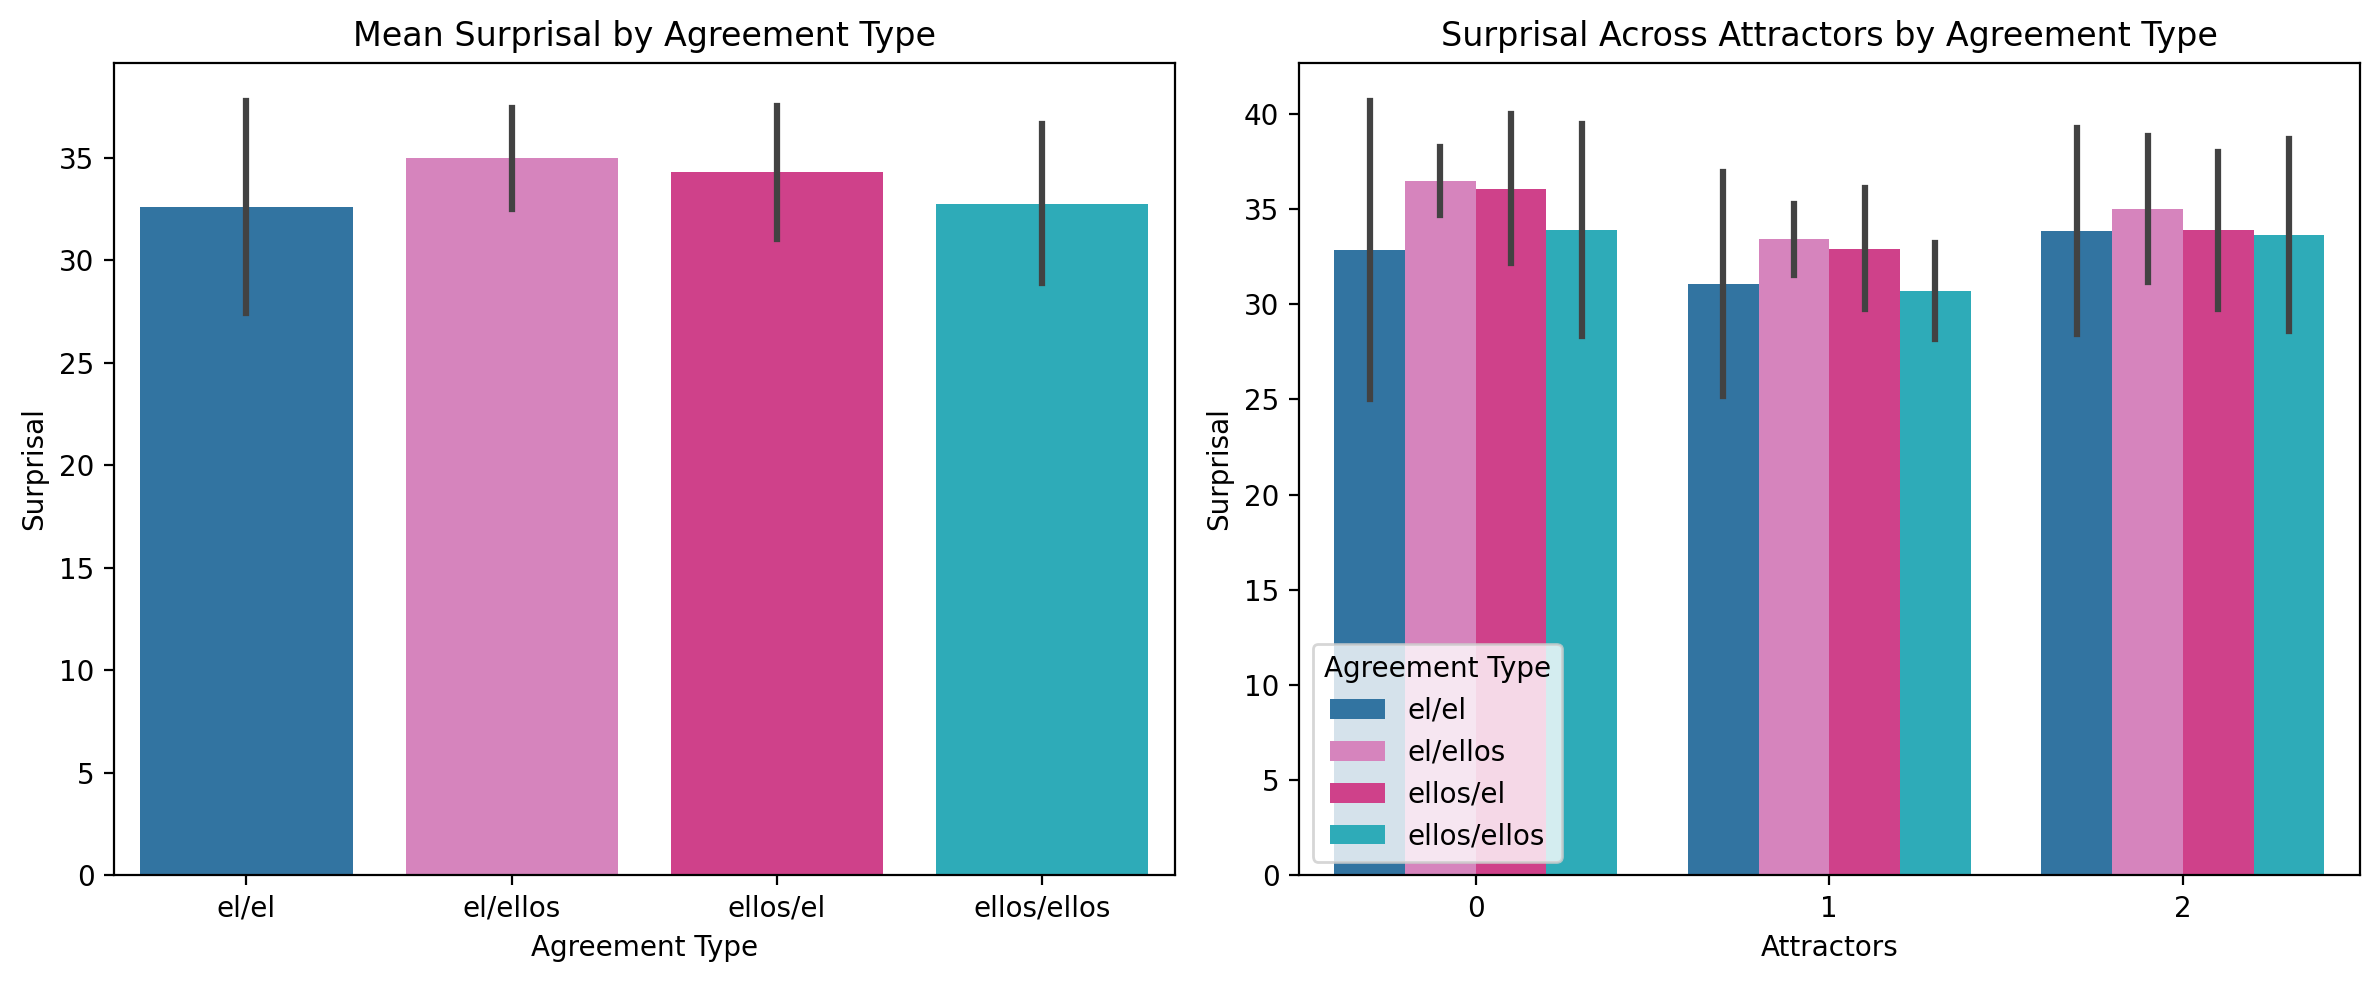

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# first plot: Surprisal by Agreement Type
sns.barplot(
    data = df_results,
    x = 'Agreement Type',
    y = 'Surprisal',
    hue = 'Agreement Type',
    palette = agreement_palette,
    errorbar = 'sd',
    ax = axes[0]
)
axes[0].set_title('Mean Surprisal by Agreement Type')

# second plot: Surprisal across Attractors
sns.barplot(
    data = df_results,
    x = 'Attractors',
    y = 'Surprisal',
    hue = 'Agreement Type',
    palette = agreement_palette,
    errorbar = 'sd',
    ax = axes[1]
)
axes[1].set_title('Surprisal Across Attractors by Agreement Type')

plt.tight_layout()
plt.show()

Switching to examining surprisal by agreement type, I can see that overall, mean surprisal across the different agreement types is quite similar, with slight decreases in surprisal for grammatically matching conditions el/el and ellos/ellos. There appears to be a slightly higher mean surprisal for el/ellos agreement over ellos/el agreement. Additionally, the error bar for el/ellos agreement appears to be the smallest, indicating that surprisal values for this ungrammatical agreement type are typically consistently high, compared to the other agreement types which have more variability. So, this could indicate a higher sensitivity to el/ellos (dis)agreement. However, again all of these differences seem quite small, and overlapping error bars indicate that these differences may not be significant at all.

Looking specifically across attractors, this trend seems to hold still, however two attractors has the least amount of difference between the surprisal for different agreement types, again showing that sensitivity to subject-verb agreement decreases with increased attractors.

### Surprisal by Agreement Type Distribution

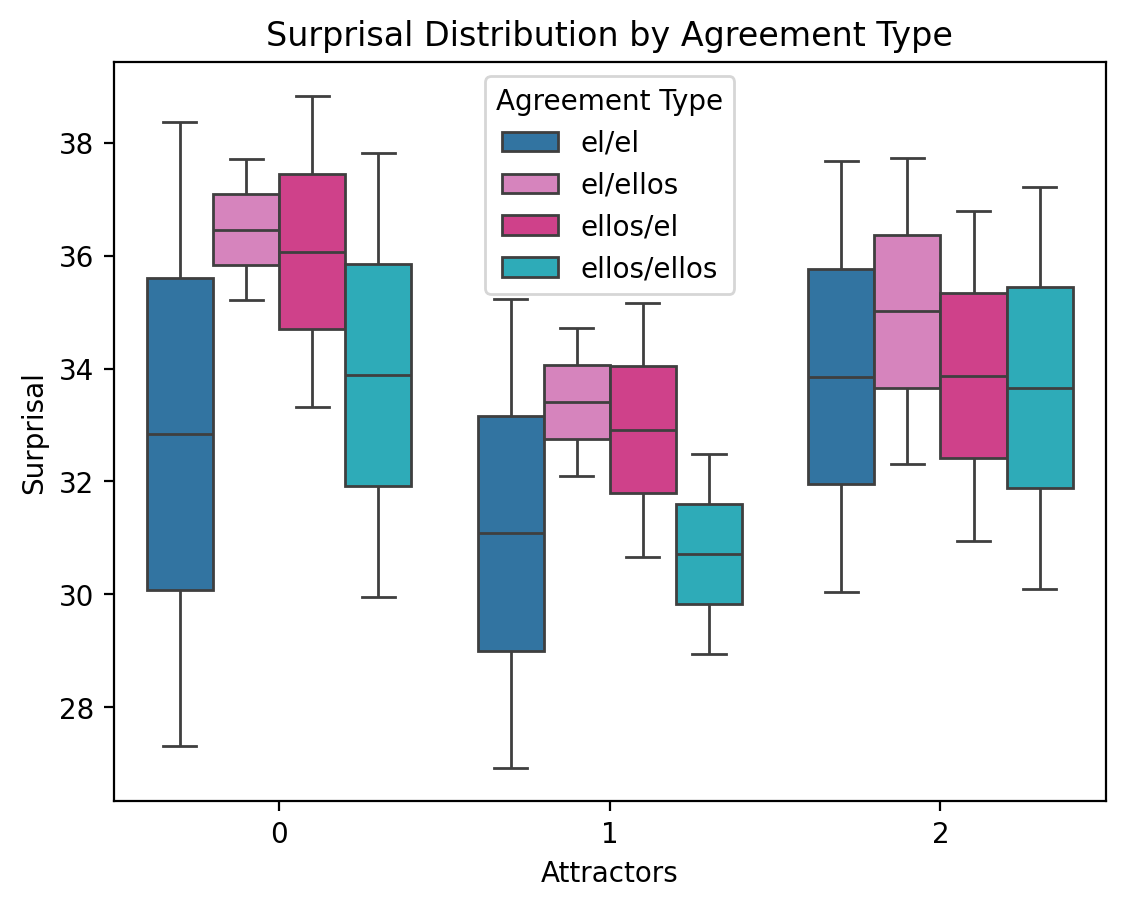

In [123]:
sns.boxplot(data = df_results, x = 'Attractors', y = 'Surprisal', hue = 'Agreement Type', palette = agreement_palette)
plt.title('Surprisal Distribution by Agreement Type')
plt.show()

Looking more specifically at the distrbution for surprisal for agreement type across attractors, I can see that the difference in the median surprisal between el/el agreement and el/ellos agreement tends to be the highest (higher than ellos/el vs ellos/ellos). So interestingly, it is likely that there is more sensitivity in the direction of singular noun-plural verb violations than in plural noun-singular verb violations. And once again, I can see that there tends to be this decrease in difference in surprisal in the two attractor condition, reinforcing the idea that increasing attractors results in decreasing sensitivity.

## Discussion & Conclusion

Overall, I discovered that the Spanish LLM GPT2-Spanish from DeepESP appears to show only a little sensitivity to subject-verb agreement, having decreasing sensitivity with increasing attractors. These results are similar to those found in the Linzen et. al. 2016 paper, where they tested LSTMs that existed at the time. This tells me that this Spanish LLM from 2025 is on par with that of an outdated LSTM from almost 10 years ago. Again, the model's small size likely has a large hand in these results. It would be interesting to see if these results could be replicated in other Spanish LLMs to isolate whether some of these results are due to just this model specifically or the Spanish language in LLMs generally.

My first thought upon finding these results is that there is an expansion that needs to be made on LLMs for other languages beyond English. And while it is true that this is definitely an area that can be expanded upon for better LLM performance, I wonder, is improving LLMs for other lanugaes really very necessary? If you view LLMs as an overall positive or good tool for society, then definitely it's important to ensure that good is available to all different languages and not just biased in advancement towards English. However, advancements of LLMs are not to be seen in a singular light. While advacement may sound good, what are the actual implications? LLMs like ChatGPT seem to have gained a whirlwind of prominence once they advanced to the point of being a certain, quite high level of usefulness. This widespread prevalence of LLMs in the US is one that has quickly become an issue for the integrity of education, among many other consequences of this expanding technology. If advancement bring prevalence which brings tons of other societal issues, would expanding LLMs to the point where they are very useful to other societies and thus utilized widely actually be a benefit? 

The perspective people have on LLMs varies greatly just from person to person, and even more so from country to country. From beliefs of LLMs bearing a new era of living to beliefs of their world-ending (or just human-eradicating) capabilities, the opinions of what LLM expansion means is about as wide of a spectrum as you can get. Those who care about the expansion of LLMs seem to be largely English-speaking people, in my limited knowledge - I am not a researcher in LLMs who frequent conferences or anything of the like, so my perspective is rather uninformed. Nonetheless, from my personal experience as a student living in the US, the focus in English LLMs is on great expansion - how can we make them "better", whatever way we interpret it? However, I have heard that priorities in terms of LLMs are very different in even another English-speaking country, such as say European countries. How much will that variance become even greater as we consider countries and cultures where English is not the primary language? Perhaps expanding LLMs of other languages could even be seen as a form of Westernization, continuing colonization, imposing different ways of living that were never wanted, asked for, or needed. Where we choose to expand AI is a largely political action that needs to be taken with intense consideration and care. 

Ultimately, expanding LLMs into other languages is not just a technical task; it's a political, cultural, and ethical one. While improving performance across languages may seem like a step toward inclusivity, it also risks reproducing the same power imbalances and societal issues that have followed LLM expansion in English. As we move forward in developing these tools, we should ask not just how we can make them better, but for who and at what cost. The question is no longer just about whether a model can agree with its subject, but whether we are agreeing, as a global society, on the kind of future we want these models to help create.